In [1]:
try:
    from pytabkit import TabM_D_Classifier, RealMLP_TD_Classifier
except:
    !uv pip install pytabkit
    from pytabkit import TabM_D_Classifier, RealMLP_TD_Classifier

try:
    import xgboost as xgb
except:
    !uv pip install xgboost
    import xgboost as xgb

Using Python 3.12.13 environment at: /usr
Resolved 55 packages in 816ms
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
Prepared 1 package in 120ms
Installed 1 package in 7ms
 + pytabkit==1.7.3


In [2]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'GPU: Tesla T4'

In [3]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import itertools
from tqdm import tqdm
from time import time, sleep

## -- Machine Learning --
import tensorflow as tf

from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, TargetEncoder as sklearnTE

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

print("📚 Libraries imported")

📚 Libraries imported


In [4]:
## -- Set Configuration --
# sklearn.set_config(transform_output="pandas")
# pd.options.mode.copy_on_write = True
pd.set_option("display.max_columns", 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    # "figure.facecolor": '#0f0f1a', # Outer panel (figure)
    # "axes.facecolor":   '#1a1a2e', # Inner panel (image)
    # "axes.edgecolor":   '#444466',
    # "axes.labelcolor":  '#e0e0ff',
    # "text.color":       'lightblue',
    # "xtick.color":      '#e0e0ff',
    # "ytick.color":      '#e0e0ff',
    # "grid.color":       '#2a2a4a',
    # "grid.alpha":       0.5,
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS':   5,
    'SEED':    42,
    'GREEN':  '\033[32m',
    'YELLOW': '\033[33m',
    'RED':    '\033[31m',
    'RESET':  '\033[0m'
}

print(f"CLASSIC")
print(f"{CFG['GREEN']} GREEN {CFG['RESET']}")
print(f"{CFG['YELLOW']} YELLOW {CFG['RESET']}")
print(f"{CFG['RED']} RED {CFG['RESET']}")

tf.keras.utils.set_random_seed(CFG['SEED'])

CLASSIC
 GREEN 
 YELLOW 
 RED 


In [5]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = "kaggle" # -> 'colab' 'kaggle'

if PLATFORM == "kaggle":
    PATH = "/kaggle/input/competitions/playground-series-s6e8/"
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = "/kaggle/input/datasets/jimarahman/smartphone-usage-and-addiction-analysis-dataset/"
    orig = pd.read_csv(ORIG_PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = "/content/drive/MyDrive/-- shared_notebooks --/Ps6e8 | Phone Addiction/_phone_addiction_data/"
    submit = pd.read_csv(PATH+"sample_submission.csv")
    train = pd.read_csv(PATH+"train.csv")
    test = pd.read_csv(PATH+"test.csv")
    orig = pd.read_csv(PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

## ----------------------------------------------------------------------------------------

ID      = "id"
TARGET  = "addicted_label"
OBJECTS = train.select_dtypes(include=["object", "category"]).columns.tolist()

CATS = [c for c in OBJECTS if c not in [TARGET, ID]]
NUMS = [c for c in train.columns if c not in CATS+[TARGET, ID]]
BASE = NUMS + CATS

for (name, df) in {"Train": train, "Test": test , "Orig": orig}.items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (691369, 14)
Test shape: (296302, 13)
Orig shape: (7500, 16)

Total Numerical: 9
Total Categorical: 3
Total base features: 12


In [6]:
display(train.head())
train.info()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [7]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,691369.0,345684.000000,199581.183466,0.00,172842.00,345684.00,518526.00,691368.00
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


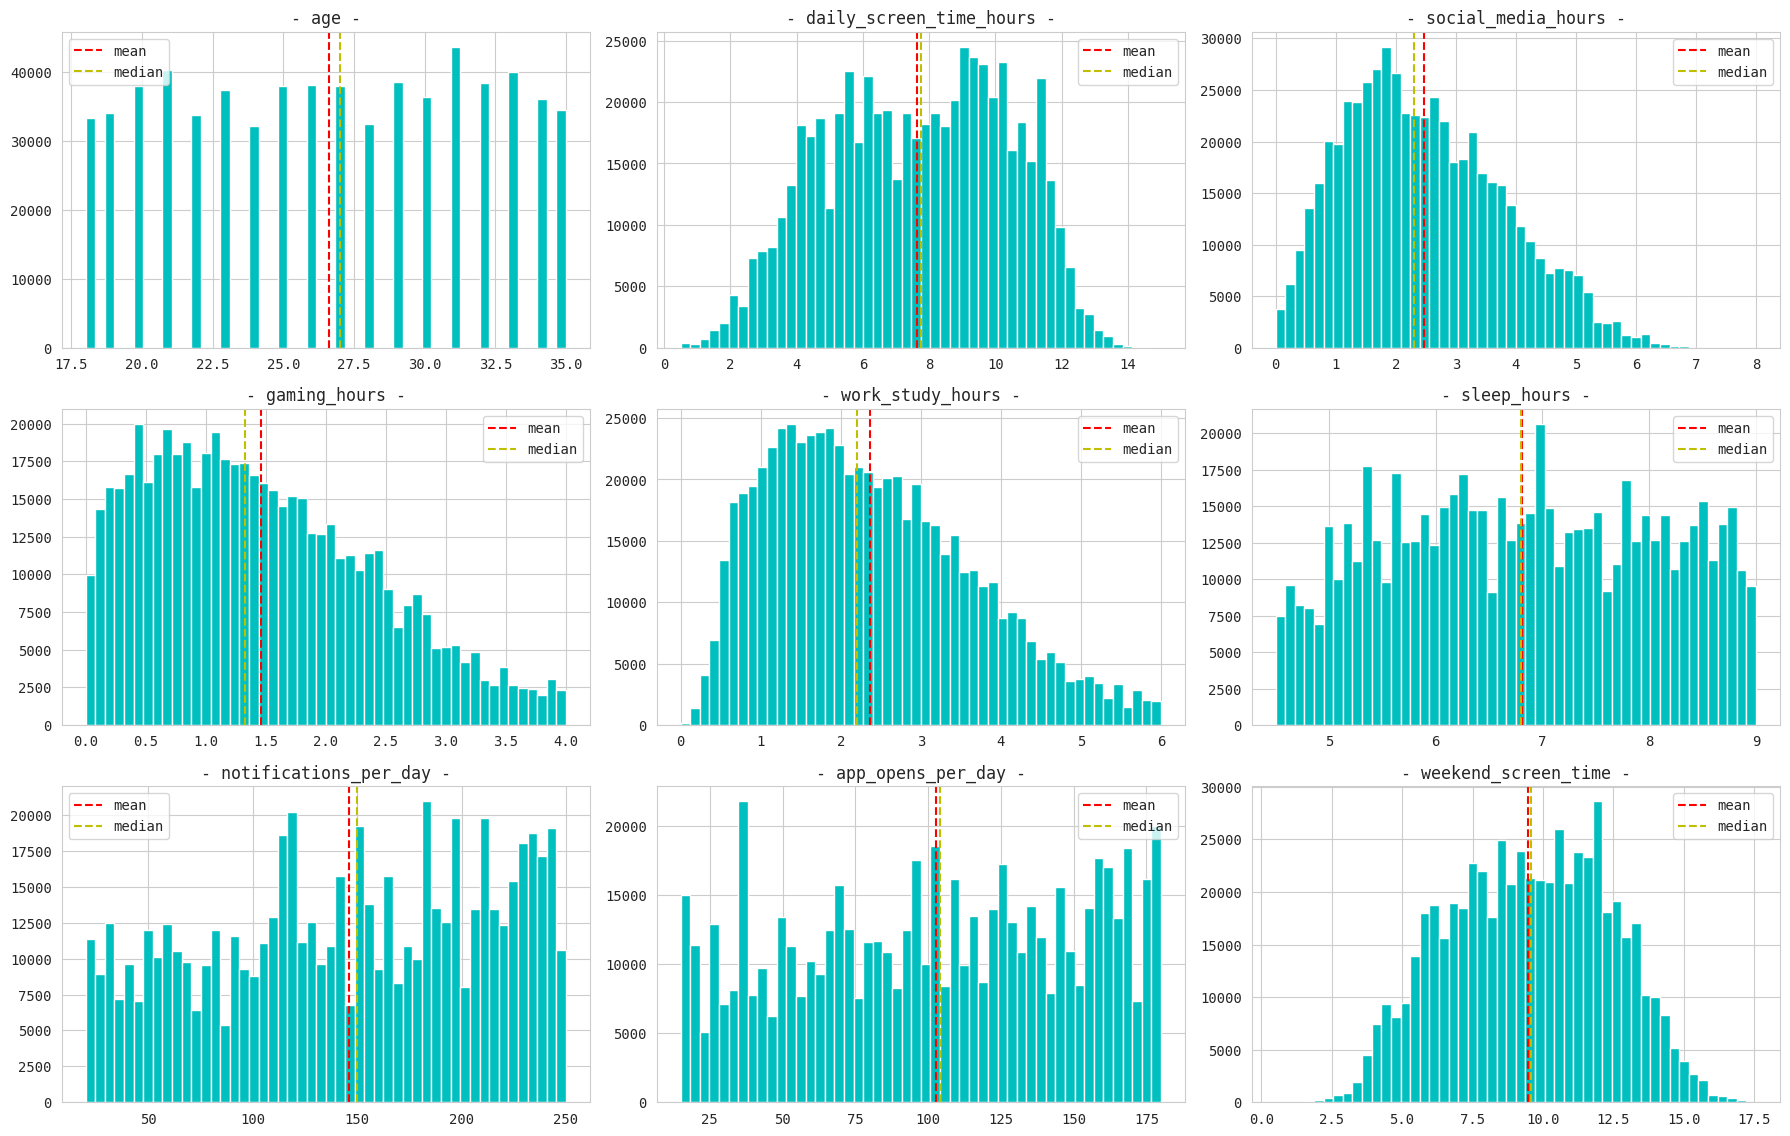

In [8]:
plt.figure(figsize=(18, 15))

for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='y', linestyle='--', label='median')
    plt.title(f'- {col} -')
    plt.legend()

plt.tight_layout()
plt.show()

In [9]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIG_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIG_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIG_UNIQUE, index=['Orig']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.T.sort_values(by="Train").style.background_gradient(subset="Train")

,Train,Orig,Test
academic_work_impact,2,2,2
gender,3,3,3
stress_level,3,3,3
age,18,18,18
app_opens_per_day,166,166,166
notifications_per_day,231,231,231
gaming_hours,401,401,401
sleep_hours,451,451,451
work_study_hours,600,551,601
social_media_hours,721,551,703


In [10]:
n_unique = train[BASE].nunique().sort_values()
n_unique

academic_work_impact          2
gender                        3
stress_level                  3
age                          18
app_opens_per_day           166
notifications_per_day       231
gaming_hours                401
sleep_hours                 451
work_study_hours            600
social_media_hours          721
daily_screen_time_hours    1389
weekend_screen_time        1437
dtype: int64

## FEATURE ENGINEERING

In [11]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [12]:
# for col in NUMS:
#     # print(f"\nRounding... ", end='')
#     # for r in range(-2, 3):
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')

#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)

#     print(f"\nDIGITS... ", end='')
#     for d in range(-3, 3):
#         d_n = f'{col}_digit_{d}'
#         print(d_n+', ', end='')
#         train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
#         test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
#         # orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

#         ## -- Drop constant features --
#         if train[d_n].nunique() < digit_thresh:
#             DROP_COLS.append(d_n)
#         else:
#             DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [100]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nCreating quantile-based Q_BINS... ", end='')
#     # for q in [100]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [13]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: []


In [14]:
def apply_feature_engineering(df_, num_features_, cat_features_):
    df = df_.copy()

    num_to_cat = []
    for col in num_features_:
        cat_name = f"{col}_cat"
        df[cat_name] = df[col].factorize()[0]
        num_to_cat.append(cat_name)

    for c in num_features_:
        for i in [0, 1]:
            df[f"{c}_round{i}"] = df[c].round(i)

    social  = df['social_media_hours']
    gaming  = df['gaming_hours']
    work    = df['work_study_hours']
    daily   = df['daily_screen_time_hours']
    sleep   = df['sleep_hours']
    weekend = df['weekend_screen_time']
    opens   = df['app_opens_per_day']
    notifications = df['notifications_per_day']

    df['total_breakdown_hours'] = social.fillna(0) + gaming.fillna(0) + work.fillna(0)
    df['social_ratio'] = social / (daily + 1e-5)
    df['gaming_ratio'] = gaming / (daily + 1e-5)
    df['work_ratio'] = work / (daily + 1e-5)
    df['unaccounted_screen_time'] = daily - df['total_breakdown_hours']
    df['screen_to_sleep_ratio'] = daily / (sleep + 1e-5)
    df['weekend_vs_daily_ratio'] = weekend / (daily + 1e-5)
    df['app_opens_per_hour'] = opens / (daily + 1e-5)
    df['notifications_per_hour'] = notifications / (daily + 1e-5)

    COMP = ['social_media_hours', 'gaming_hours', 'work_study_hours']
    n_missing_components = df[COMP].isna().sum(axis=1)
    missing_daily = daily.isna()
    known_component_sum = df[COMP].sum(axis=1, min_count=1)
    slack = daily - known_component_sum
    daily_missing_with_components = missing_daily & (n_missing_components == 0)
    one_component_missing = (~missing_daily) & (n_missing_components == 1)
    all_screen_known = (~missing_daily) & (n_missing_components == 0)

    df['ci_daily_lb'] = np.where(daily_missing_with_components, known_component_sum, np.nan)
    df['ci_missing_comp_ub'] = np.where(one_component_missing, slack, np.nan)
    df['ci_missing_comp_mid'] = np.where(one_component_missing, np.clip(slack / 2, 0, None), np.nan)
    df['ci_interval_width'] = np.where(one_component_missing, slack, np.nan)
    df['ci_slack_exact'] = np.where(all_screen_known, slack, np.nan)
    df['ci_case'] = np.select([daily_missing_with_components, one_component_missing], [1.0, 2.0], default=0.0).astype('float32')
    df['ci_n_missing'] = (missing_daily.astype('int8') + n_missing_components).astype('float32')

    df['missing_count'] = df[num_features_+cat_features_].isna().sum(axis=1).astype('float32')

    drop = [c for c in df.columns if df[c].nunique(dropna=False) == 1]
    if drop:
        df.drop(drop, axis=1, inplace=True)

    fe_cols = [c for c in df.columns if c not in BASE]

    if ID in fe_cols:
        fe_cols.remove(ID)
    if TARGET in fe_cols:
        fe_cols.remove(TARGET)

    return df, fe_cols

train, FE_COLS  = apply_feature_engineering(train, NUMS, CATS)
test, _ = apply_feature_engineering(test, NUMS, CATS)
orig, _ = apply_feature_engineering(orig, NUMS, CATS)

new_cats = [c for c in FE_COLS if c.endswith("_cat")]

# new_cats = ["missing_count"]
# new_cats.extend([
#     c for c in FE_COLS
#     if "_round" in c
#     or c.endswith("_cat")
#     or c.startswith("ci_")
# ])

new_nums = [c for c in FE_COLS if c not in new_cats]

# CATS.extend(new_cats)
# NUMS.extend(new_nums)

display(train[FE_COLS].head())

# train[FE_COLS].nunique().sort_values()

,age_cat,daily_screen_time_hours_cat,social_media_hours_cat,gaming_hours_cat,work_study_hours_cat,sleep_hours_cat,notifications_per_day_cat,app_opens_per_day_cat,weekend_screen_time_cat,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count
0,0,-1,0,0,0,0,0,0,0,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1.0
1,1,0,1,-1,1,1,1,1,-1,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2.0
2,2,1,-1,-1,-1,2,2,2,1,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,NaN,NaN,NaN,NaN,NaN,0.0,3.0,3.0
3,3,2,2,1,2,3,3,3,2,21.0,21.0,6.0,6.4,1.0,1.3,1.0,1.4,3.0,3.4,9.0,8.8,112.0,112.0,94.0,94.0,9.0,8.7,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,NaN,NaN,NaN,NaN,0.38,0.0,0.0,1.0
4,4,3,3,2,3,4,-1,-1,3,26.0,26.0,11.0,11.2,2.0,1.9,3.0,2.8,2.0,2.0,5.0,5.2,NaN,NaN,NaN,NaN,13.0,13.4,6.63,0.166964,0.250893,0.174107,4.57,2.133329,1.195535,NaN,NaN,NaN,NaN,NaN,NaN,4.57,0.0,0.0,2.0


In [15]:
# def add_frequency_condition(df1, cols, thresh=5):
#     df = df1.copy()
#     for c in cols:
#         v_counts = df[c].value_counts()
#         to_replace = v_counts[v_counts <= thresh].index
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [16]:
## -- Frequency encoding --
FREQ_COLS = []

print(f"\nCreating frequencies... ", end="")
for col in NUMS:
    freq = pd.concat([train[col], test[col], orig[col]]).value_counts(dropna=False, normalize=True) #
    n = f"{col}_FREQ"
    print(n+", ", end="")
    for df in [train, test, orig]:
        df[n] = df[col].map(freq).fillna(0).astype("float32")
    FREQ_COLS.append(n)

print(f"\n✓ Total frequency features: {len(FREQ_COLS)}")

train[NUMS+FREQ_COLS]


Creating frequencies... age_FREQ, daily_screen_time_hours_FREQ, social_media_hours_FREQ, gaming_hours_FREQ, work_study_hours_FREQ, sleep_hours_FREQ, notifications_per_day_FREQ, app_opens_per_day_FREQ, weekend_screen_time_FREQ, 
✓ Total frequency features: 9


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,age_FREQ,daily_screen_time_hours_FREQ,social_media_hours_FREQ,gaming_hours_FREQ,work_study_hours_FREQ,sleep_hours_FREQ,notifications_per_day_FREQ,app_opens_per_day_FREQ,weekend_screen_time_FREQ
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,0.046406,0.129266,0.002680,0.002655,0.004208,0.004194,0.005188,0.007454,0.002292
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,0.049082,0.001613,0.001716,0.187145,0.001559,0.000855,0.007745,0.005633,0.163550
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,0.047898,0.000713,0.182272,0.187145,0.079680,0.005797,0.002166,0.004077,0.001595
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,0.057899,0.000820,0.002494,0.002573,0.002378,0.002358,0.008818,0.005310,0.000615
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,0.054907,0.000480,0.003234,0.001878,0.002928,0.002653,0.102299,0.106931,0.000533
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,0.048841,0.000917,0.002738,0.003255,0.003730,0.003061,0.002960,0.005310,0.001807
691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,0.054722,0.001172,0.003309,0.002263,0.000501,0.003874,0.005318,0.009931,0.002690
691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,0.046291,0.129266,0.182272,0.187145,0.003060,0.001770,0.102299,0.002160,0.001274
691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,0.048841,0.001420,0.001785,0.002101,0.003872,0.001106,0.002876,0.002794,0.001712


In [17]:
## -- Cyclic encoding --
CYCLICS = []
cy_cols = [c for c in train.columns if c.endswith("_hours")]

for col in tqdm(cy_cols):
    for p in [12, 24]:
        n_s = f"{col}_sin_{p}"

        train[n_s] = np.sin(2 * np.pi * train[col] / p).astype('float32')
        orig[n_s]  = np.sin(2 * np.pi * orig[col] / p).astype('float32')
        test[n_s]  = np.sin(2 * np.pi * test[col] / p).astype('float32')
        CYCLICS.append(n_s)

        # n_c = f"{col}_cos_{p}"
        # train[n_c] = np.cos(2 * np.pi * train[col] / p).astype('float32')
        # test[n_c] = np.cos(2 * np.pi * test[col] / p).astype('float32')
        # orig[n_c] = np.cos(2 * np.pi * orig[col] / p).astype('float32')
        # CYCLICS.append(n_c)

# NUMS.extend(CYCLICS)

print(f"Cylcic Features created: {len(CYCLICS)}")
print(train[CYCLICS].describe().T)

train[CYCLICS].head()

100%|██████████| 6/6 [00:00<00:00, 20.50it/s]


Cylcic Features created: 12
                                   count      mean       std       min  \
daily_screen_time_hours_sin_12  595515.0 -0.236168  0.669038 -1.000000   
daily_screen_time_hours_sin_24  595515.0  0.694852  0.308752 -0.707107   
social_media_hours_sin_12       557374.0  0.749730  0.248776 -0.866025   
social_media_hours_sin_24       557374.0  0.565418  0.249960  0.000000   
gaming_hours_sin_12             564548.0  0.605986  0.297661  0.000000   
gaming_hours_sin_24             564548.0  0.360581  0.215976  0.000000   
work_study_hours_sin_12         639851.0  0.751345  0.235980  0.000000   
work_study_hours_sin_24         639851.0  0.547345  0.242554  0.000000   
sleep_hours_sin_12              646889.0 -0.328998  0.522602 -1.000000   
sleep_hours_sin_24              646889.0  0.927656  0.080077  0.707107   
total_breakdown_hours_sin_12    691369.0  0.153326  0.713027 -1.000000   
total_breakdown_hours_sin_24    691369.0  0.795909  0.221083 -0.621148   

         

,daily_screen_time_hours_sin_12,daily_screen_time_hours_sin_24,social_media_hours_sin_12,social_media_hours_sin_24,gaming_hours_sin_12,gaming_hours_sin_24,work_study_hours_sin_12,work_study_hours_sin_24,sleep_hours_sin_12,sleep_hours_sin_24,total_breakdown_hours_sin_12,total_breakdown_hours_sin_24
0,NaN,NaN,0.818150,0.460974,0.739631,0.404344,0.893371,0.524729,-0.692143,0.927836,0.243615,0.992439
1,0.015707,0.999969,0.535827,0.278991,NaN,NaN,0.999877,0.712638,-0.917755,0.835807,0.835807,0.880063
2,0.458650,0.971755,NaN,NaN,NaN,NaN,NaN,NaN,-0.130526,0.997859,0.000000,0.000000
3,-0.218143,0.993961,0.612907,0.323917,0.676876,0.363251,0.982287,0.770513,-0.996917,0.734322,-0.020942,0.999945
4,-0.406737,0.207912,0.830012,0.470242,0.995056,0.671074,0.852640,0.488621,0.382683,0.980785,-0.323917,0.986429


In [18]:
# INTER = []

# for c1, c2 in tqdm(list(itertools.combinations(DIGITS, 2)), desc='Pairwise'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     # orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# # for c1, c2, c3 in tqdm(list(itertools.combinations(CATS, 3)), desc='Triplewise'):
# #     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
# #     INTER.append(n_col)

# # for c1, c2 in tqdm(list(itertools.product(CATS, DIGITS)), desc='One-to-Many'):
# #     n_col = f"Bi_{c1}-|-{c2}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
# #     # orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
# #     INTER.append(n_col)

# print(f"Total Interaction Features: {len(INTER)}")

In [19]:
# train["orig_preds"] = np.load(
#     "/kaggle/input/datasets/sylvesterdalmeida/ps6e8-original-prediction/ag_best_addicted_label_train.npy"
# )

# test["orig_preds"]  = np.load(
#     "/kaggle/input/datasets/sylvesterdalmeida/ps6e8-original-prediction/ag_best_addicted_label_test.npy"
# )

In [20]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/CategoryMean ENCODERS =====

class customTE(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in tqdm(self.cols_to_encode, desc="TE encoding"):
            for agg_func in self.aggs:
                new_col_name = f"TE_{col}_{agg_func}"
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f"TE_{col}_{agg_func}"

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [21]:
def original_TE(
    orig: pd.DataFrame,
    df: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return df.copy()

    if aggs is None or len(aggs) == 0:
        return df.copy()

    X_df = df.copy()

    orig_cols = []
    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    pbar = tqdm(valid_features)
    for col in pbar:
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"oTE_{col}_{agg_key}"
            pbar.set_description(f"Augmenting {col}")
            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_df = X_df.merge(map_df, on=col, how='left')

            orig_cols.append(new_col)

        pbar.set_description(f"Original augment complete!")

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in orig_cols:
            if c.endswith(('_mean', '_max', '_min')):
                df[c] = df[c].fillna(global_mean)
            elif c.endswith('_median'):
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_df = fill_conditionally(X_df)

    return X_df, orig_cols

print("-- Data augment function ready! --")

-- Data augment function ready! --


In [22]:
# ## -- "mean", "median", "count", "std", "skew", "nunique", "max", "min"
# orig_aggs = ["median", "count", "std"]

# train, orig_cols = orig_TE_data_propagate(
#     orig,
#     train,
#     features=BASE,
#     target=TARGET,
#     aggs=orig_aggs,
#     fill_nan=True,
# )

# test, _ = orig_TE_data_propagate(
#     orig,
#     test,
#     features=BASE,
#     target=TARGET,
#     aggs=orig_aggs,
#     fill_nan=True,
# )

# train[orig_cols][:10].T

In [23]:
# train["orig_preds"] = np.load(
#     "/kaggle/input/datasets/sylvesterdalmeida/ps6e8-original-prediction/ag_best_addicted_label_train.npy"
# )

# test["orig_preds"]  = np.load(
#     "/kaggle/input/datasets/sylvesterdalmeida/ps6e8-original-prediction/ag_best_addicted_label_test.npy"
# )

In [24]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print("Total Features:", len(FEATURES))

combined = pd.concat([train, test, orig])
## ------------------------------------------------------------
# # -- Duplicate Nums as Cats --
# CATS_2 = []
# for c in tqdm(NUMS, title="nums_to_cats"):
#     n = f"{c}_cat"
#     combined[n] = combined[c].copy()
#     CATS_2.append(n)
# FEATURES.extend(CATS_2)
## ------------------------------------------------------------
## -- Factorize CATS --
for c in tqdm(CATS, desc="factorize_cats"): # +INTER + new_cats
    combined[c] = combined[c].factorize()[0]

for c in tqdm(CATS, desc="categorize_cats"):
    combined[c] = combined[c].astype("category")

train = combined.iloc[:len(train)][FEATURES+[TARGET]]
test  = combined.iloc[len(train):len(train)+len(test)][FEATURES]
orig  = combined.iloc[len(train)+len(test):]

del combined

Total Features: 77


categorize_cats: 100%|██████████| 3/3 [00:00<00:00, 91.28it/s]


In [25]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
FEATURES = list(set(FEATURES))

print("Total Features:", len(FEATURES))

train

Total Features: 77


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,age_cat,daily_screen_time_hours_cat,social_media_hours_cat,gaming_hours_cat,work_study_hours_cat,sleep_hours_cat,notifications_per_day_cat,app_opens_per_day_cat,weekend_screen_time_cat,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count,age_FREQ,daily_screen_time_hours_FREQ,social_media_hours_FREQ,gaming_hours_FREQ,work_study_hours_FREQ,sleep_hours_FREQ,notifications_per_day_FREQ,app_opens_per_day_FREQ,weekend_screen_time_FREQ,daily_screen_time_hours_sin_12,daily_screen_time_hours_sin_24,social_media_hours_sin_12,social_media_hours_sin_24,gaming_hours_sin_12,gaming_hours_sin_24,work_study_hours_sin_12,work_study_hours_sin_24,sleep_hours_sin_12,sleep_hours_sin_24,total_breakdown_hours_sin_12,total_breakdown_hours_sin_24,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,0,0,0,0,-1,0,0,0,0,0,0,0,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0.046406,0.129266,0.002680,0.002655,0.004208,0.004194,0.005188,0.007454,0.002292,NaN,NaN,0.818150,0.460974,0.739631,0.404344,0.893371,0.524729,-0.692143,0.927836,0.243615,0.992439,1.0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,1,0,0,1,0,1,-1,1,1,1,1,-1,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2.0,0.049082,0.001613,0.001716,0.187145,0.001559,0.000855,0.007745,0.005633,0.163550,0.015707,0.999969,0.535827,0.278991,NaN,NaN,0.999877,0.712638,-0.917755,0.835807,0.835807,0.880063,0.0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,1,1,1,2,1,-1,-1,-1,2,2,2,1,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,NaN,NaN,NaN,NaN,NaN,0.0,3.0,3.0,0.047898,0.000713,0.182272,0.187145,0.079680,0.005797,0.002166,0.004077,0.001595,0.458650,0.971755,NaN,NaN,NaN,NaN,NaN,NaN,-0.130526,0.997859,0.000000,0.000000,0.0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,2,1,-1,3,2,2,1,2,3,3,3,2,21.0,21.0,6.0,6.4,1.0,1.3,1.0,1.4,3.0,3.4,9.0,8.8,112.0,112.0,94.0,94.0,9.0,8.7,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,NaN,NaN,NaN,NaN,0.38,0.0,0.0,1.0,0.057899,0.000820,0.002494,0.002573,0.002378,0.002358,0.008818,0.005310,0.000615,-0.218143,0.993961,0.612907,0.323917,0.676876,0.363251,0.982287,0.770513,-0.996917,0.734322,-0.020942,0.999945,1.0
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,1,0,0,4,3,3,2,3,4,-1,-1,3,26.0,26.0,11.0,11.2,2.0,1.9,3.0,2.8,2.0,2.0,5.0,5.2,NaN,NaN,NaN,NaN,13.0,13.4,6.63,0.166964,0.250893,0.174107,4.57,2.133329,1.195535,NaN,NaN,NaN,NaN,NaN,NaN,4.57,0.0,0.0,2.0,0.054907,0.000480,0.003234,0.001878,0.002928,0.002653,0.102299,0.106931,0.000533,-0.406737,0.207912,0.830012,0.470242,0.995056,0.671074,0.852640,0.488621,0.382683,0.980785,-0.323917,0.986429,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

# ML TRAINING

In [26]:
real_params = {
    ## --- Model architecture ---
    'n_ens': 8, 
    'embedding_size': 8,
    # 'max_one_hot_cat_size': 8,
    'hidden_sizes': [512, 512, 512],
    'p_drop': 0.06,
    'p_drop_sched': "flat_cos",
    'act': 'selu', # 🔥
    'act_lr_factor': 0.5,
    'add_front_scale': True,

    ## --- PBLD (periodic) embedding for numericals ---
    'num_emb_type': 'pbld',
    'plr_hidden_1': 16,
    'plr_hidden_2': 8,
    'plr_sigma': 5.0,
    'plr_lr_factor': 0.093,
    'plr_act_name': 'prelu',

    ## --- Optimizer ---
    'lr': 0.02, # 🔥
    'mom': 0.9,
    'sq_mom': 0.98, 
    'lr_sched': 'flat_cos',
    'wd': 0.012,
    'first_layer_lr_factor': 1.0,
    'weight_lr_factor': 0.5,

    ## --- Label smoothing ---
    'ls_eps': 0.04,
    'ls_eps_sched': "cos", #'cos', "coslog4"

    ## --- Processing ---
    'tfms': ['median_center', 'robust_scale'],

    ## --- Training loop ---
    'n_epochs': 20,
    'batch_size': 256,
    'predict_batch_size': 10240,
    'verbosity': 2,

    ## --- Early stopping ---
    'use_early_stopping': True,
    'early_stopping_additive_patience': 5,
    'early_stopping_multiplicative_patience': 1,
    
    # 'bias_init_mode': 'neg-uniform-dynamic-2', # def='he+5', # 'neg-uniform-dynamic-2',
    
    # 'device': 'cuda',
    'random_state': CFG['SEED'],
    'val_metric_name': "1-auc_ovr",
}

tabm_params = {
    'arch_type': "tabm-mini-normal",
    'num_emb_type': 'pwl',
    # 'allow_amp': True,
    'lr': 0.002, # 🔥
    # 'batch_size': 256,
    # 'd_block': 512,
    'n_epochs': 20,
    'patience': 3,
    'n_blocks': 3,
    'd_embedding': 16,
    # 'dropout': 0.05,
    # 'weight_decay': 0.01,
    # 'tabm_k': 24, # 32
    # 'num_emb_n_bins': 24,
    # 'gradient_clipping_norm': 1.0,
    'verbosity': 2,
    'random_state': CFG['SEED'],
    'device': "cuda" if torch.cuda.is_available() else "cpu",
    'val_metric_name': "1-auc_ovr",
}

nn_params = {
    "tabm": tabm_params,
    "realmlp": real_params,
}

nn_params

{'tabm': {'arch_type': 'tabm-mini-normal',
  'num_emb_type': 'pwl',
  'lr': 0.002,
  'n_epochs': 20,
  'patience': 3,
  'n_blocks': 3,
  'd_embedding': 16,
  'verbosity': 2,
  'random_state': 42,
  'device': 'cuda',
  'val_metric_name': '1-auc_ovr'},
 'realmlp': {'n_ens': 8,
  'embedding_size': 8,
  'hidden_sizes': [512, 512, 512],
  'p_drop': 0.06,
  'p_drop_sched': 'flat_cos',
  'act': 'selu',
  'act_lr_factor': 0.5,
  'add_front_scale': True,
  'num_emb_type': 'pbld',
  'plr_hidden_1': 16,
  'plr_hidden_2': 8,
  'plr_sigma': 5.0,
  'plr_lr_factor': 0.093,
  'plr_act_name': 'prelu',
  'lr': 0.02,
  'mom': 0.9,
  'sq_mom': 0.98,
  'lr_sched': 'flat_cos',
  'wd': 0.012,
  'first_layer_lr_factor': 1.0,
  'weight_lr_factor': 0.5,
  'ls_eps': 0.04,
  'ls_eps_sched': 'cos',
  'tfms': ['median_center', 'robust_scale'],
  'n_epochs': 20,
  'batch_size': 256,
  'predict_batch_size': 10240,
  'verbosity': 2,
  'use_early_stopping': True,
  'early_stopping_additive_patience': 5,
  'early_stoppi

In [27]:
LR = 0.015

grad_params = {
    'sampling_method': "gradient_based",
    # ------------------------------------
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "enable_categorical": True,
    "n_estimators": 30_000,
    "learning_rate": LR,
    "max_depth": 6,
    "subsample": 0.2,
    "colsample_bytree": 0.3,
    "reg_alpha": 5.0, # 5.0
    "reg_lambda": 10.0, # 10.0
    "min_child_weight": 40, # 40
    # "max_bins": outer,
    # "scale_pos_weight": sum(train[TARGET] == 0) / sum(train[TARGET] == 1),
    "random_state": CFG['SEED'] + 2,
    "verbosity": 0,
    "n_jobs": -1,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

loss_params = {
    "grow_policy": "lossguide",
    # ----------------------------------
    "max_leaves": 64,
    "max_depth": 10, # 10, 0
    # ----------------------------------
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "enable_categorical": True,
    "n_estimators": 30_000,
    "learning_rate": LR,
    "subsample": 0.9,
    "colsample_bytree": 0.4,
    "reg_alpha": 0.5, # 0.5, 5.0
    "reg_lambda": 5.0, # 5.0, 10.0
    "min_child_weight": 20, # 20, 40
    # "max_bins": outer,
    # "scale_pos_weight": sum(train[TARGET] == 0) / sum(train[TARGET] == 1),
    "random_state": CFG['SEED'] + 1,
    "verbosity": 0,
    "n_jobs": -1,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
} 

gbt_params = {
    # ------------------------------------
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "enable_categorical": True,
    "n_estimators": 30_000,
    "learning_rate": LR,
    "max_depth": 6,
    "subsample": 0.9,
    "colsample_bytree": 0.6,
    "reg_alpha": 1.0, # 1.0, 3.0,
    "reg_lambda": 5.0, # 5.0, 10.0,
    "min_child_weight": 10, # 10, 50,
    # ------------------------------------
    # "max_bins": 780,
    # "scale_pos_weight": sum(train[TARGET] == 0) / sum(train[TARGET] == 1),
    "random_state": CFG['SEED'],
    "verbosity": 0,
    "n_jobs": -1,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

xgb_params = {
    "gbt": gbt_params,
    "loss": loss_params,
    "grad": grad_params,
}

xgb_params

{'gbt': {'objective': 'binary:logistic',
  'eval_metric': 'auc',
  'enable_categorical': True,
  'n_estimators': 30000,
  'learning_rate': 0.015,
  'max_depth': 6,
  'subsample': 0.9,
  'colsample_bytree': 0.6,
  'reg_alpha': 1.0,
  'reg_lambda': 5.0,
  'min_child_weight': 10,
  'random_state': 42,
  'verbosity': 0,
  'n_jobs': -1,
  'device': 'cuda'},
 'loss': {'grow_policy': 'lossguide',
  'max_leaves': 64,
  'max_depth': 10,
  'objective': 'binary:logistic',
  'eval_metric': 'auc',
  'enable_categorical': True,
  'n_estimators': 30000,
  'learning_rate': 0.015,
  'subsample': 0.9,
  'colsample_bytree': 0.4,
  'reg_alpha': 0.5,
  'reg_lambda': 5.0,
  'min_child_weight': 20,
  'random_state': 43,
  'verbosity': 0,
  'n_jobs': -1,
  'device': 'cuda'},
 'grad': {'sampling_method': 'gradient_based',
  'objective': 'binary:logistic',
  'eval_metric': 'auc',
  'enable_categorical': True,
  'n_estimators': 30000,
  'learning_rate': 0.015,
  'max_depth': 6,
  'subsample': 0.2,
  'colsample_b

In [28]:
train[FEATURES].columns == test[FEATURES].columns

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [29]:
all_predictions = {}

CFG['FOLDS'] = 5
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

USE_FULL_TRAIN = True
x_sample, x_sample2 = train_test_split(train, train_size=0.1, stratify=train[TARGET], random_state=0)
train_data = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True).copy()

train_data

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,age_cat,daily_screen_time_hours_cat,social_media_hours_cat,gaming_hours_cat,work_study_hours_cat,sleep_hours_cat,notifications_per_day_cat,app_opens_per_day_cat,weekend_screen_time_cat,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count,age_FREQ,daily_screen_time_hours_FREQ,social_media_hours_FREQ,gaming_hours_FREQ,work_study_hours_FREQ,sleep_hours_FREQ,notifications_per_day_FREQ,app_opens_per_day_FREQ,weekend_screen_time_FREQ,daily_screen_time_hours_sin_12,daily_screen_time_hours_sin_24,social_media_hours_sin_12,social_media_hours_sin_24,gaming_hours_sin_12,gaming_hours_sin_24,work_study_hours_sin_12,work_study_hours_sin_24,sleep_hours_sin_12,sleep_hours_sin_24,total_breakdown_hours_sin_12,total_breakdown_hours_sin_24,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,0,0,0,0,-1,0,0,0,0,0,0,0,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0.046406,0.129266,0.002680,0.002655,0.004208,0.004194,0.005188,0.007454,0.002292,NaN,NaN,0.818150,0.460974,0.739631,0.404344,0.893371,0.524729,-0.692143,0.927836,0.243615,0.992439,1.0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,1,0,0,1,0,1,-1,1,1,1,1,-1,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2.0,0.049082,0.001613,0.001716,0.187145,0.001559,0.000855,0.007745,0.005633,0.163550,0.015707,0.999969,0.535827,0.278991,NaN,NaN,0.999877,0.712638,-0.917755,0.835807,0.835807,0.880063,0.0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,1,1,1,2,1,-1,-1,-1,2,2,2,1,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,NaN,NaN,NaN,NaN,NaN,0.0,3.0,3.0,0.047898,0.000713,0.182272,0.187145,0.079680,0.005797,0.002166,0.004077,0.001595,0.458650,0.971755,NaN,NaN,NaN,NaN,NaN,NaN,-0.130526,0.997859,0.000000,0.000000,0.0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,2,1,-1,3,2,2,1,2,3,3,3,2,21.0,21.0,6.0,6.4,1.0,1.3,1.0,1.4,3.0,3.4,9.0,8.8,112.0,112.0,94.0,94.0,9.0,8.7,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,NaN,NaN,NaN,NaN,0.38,0.0,0.0,1.0,0.057899,0.000820,0.002494,0.002573,0.002378,0.002358,0.008818,0.005310,0.000615,-0.218143,0.993961,0.612907,0.323917,0.676876,0.363251,0.982287,0.770513,-0.996917,0.734322,-0.020942,0.999945,1.0
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,1,0,0,4,3,3,2,3,4,-1,-1,3,26.0,26.0,11.0,11.2,2.0,1.9,3.0,2.8,2.0,2.0,5.0,5.2,NaN,NaN,NaN,NaN,13.0,13.4,6.63,0.166964,0.250893,0.174107,4.57,2.133329,1.195535,NaN,NaN,NaN,NaN,NaN,NaN,4.57,0.0,0.0,2.0,0.054907,0.000480,0.003234,0.001878,0.002928,0.002653,0.102299,0.106931,0.000533,-0.406737,0.207912,0.830012,0.470242,0.995056,0.671074,0.852640,0.488621,0.382683,0.980785,-0.323917,0.986429,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

In [30]:
## -- Pseudo Trainer --

XGB_TYPE = "grad" # 0->"gbt", 1->"loss", 2->"grad"
USE_REAL_MLP = False
USE_ORIGINAL = True

# Handle optional original table aggregations securely if flags enable them
if USE_ORIGINAL and "original_TE" in globals():
    feats_update = FEATURES.copy()
    aggs_ = ["mean", "count"]
    X_tr, orig_cols = original_TE(
        orig, train_data, target=TARGET, features=BASE, aggs=aggs_, fill_nan=True
    )
    x_test, _ = original_TE(
        orig, test, target=TARGET, features=BASE, aggs=aggs_, fill_nan=True
    )
    feats_update.extend(orig_cols)
    X = X_tr[feats_update].copy()
    y = X_tr[TARGET].astype("int32")
    X_ts = x_test[feats_update].copy()
else:
    X = train_data[FEATURES].copy()
    y = train_data[TARGET].astype("int32")
    X_ts = test[FEATURES].copy()

oof_preds  = np.zeros(len(X))
test_preds = np.zeros(len(X_ts))

fold_scores = []
m1_scores   = []

ALL_CATS = CATS + new_cats
NEW_NUMS = [c for c in FEATURES if c not in ALL_CATS]

t0 = time()

## -- Initiate Training --
for idx, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n{'='*70}")
    print(f"+++++ FOLD {idx}/{skf.n_splits}", end=" | ")

    X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
    X_test = X_ts.copy()

    # ## -- OPTION A: Concatenate original data --
    # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
    # y_train = pd.concat([y_train, orig[TARGET]], ignore_index=True)
    # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

    te_enc  = customTE(new_cats, cv=5, smooth='auto', aggs=['mean'], drop_original=False)
    X_train = te_enc.fit_transform(X_train, y_train)
    X_valid = te_enc.transform(X_valid)
    X_test  = te_enc.transform(X_test)

    # ---- Imputing ----
    # imputer = IterativeImputer(max_iter=20, tol=1e-3, random_state=0) # n_nearest_features=10, 
    imputer = SimpleImputer(strategy="mean")
    X_train[NEW_NUMS] = imputer.fit_transform(X_train[NEW_NUMS], y_train)
    X_valid[NEW_NUMS] = imputer.transform(X_valid[NEW_NUMS])
    X_test[NEW_NUMS]  = imputer.transform(X_test[NEW_NUMS])

    # cme_encoder = CategoryMeanTransformer(cat_cols=new_cats)
    # X_train = cme_encoder.fit_transform(X_train, y_train)
    # X_valid = cme_encoder.transform(X_valid)
    # X_test  = cme_encoder.transform(X_test)

    print(f"shape: {X_train.shape}")
    if idx == 1:
        display(X_train.head(3))

    ## -- Select base model --
    if USE_REAL_MLP:
        model_1 = RealMLP_TD_Classifier(**nn_params["realmlp"])
        m1_name = "realmlp"
    else:
        model_1 = TabM_D_Classifier(**nn_params["tabm"])
        m1_name = "tabm"

    model_1.fit(X_train, y_train, X_valid, y_valid, cat_col_names=ALL_CATS)
    oof_m1 = model_1.predict_proba(X_valid)[:, 1]
    test_m1 = model_1.predict_proba(X_test)[:, 1]

    score_m1 = roc_auc_score(y_valid, oof_m1)
    print(f"{CFG['YELLOW']} • {m1_name} AUC: {score_m1:.6f}{CFG['RESET']}")
    m1_scores.append(score_m1)

    ## -- Pseudo labels from model_1 as features for model_2 --
    X_train_full = pd.concat([X_train, X_valid, X_test]).copy()
    y_train_full = np.concatenate([y_train.to_numpy(), oof_m1, test_m1], axis=0)

    for c in ALL_CATS:
        X_train_full[c] = X_train_full[c].astype('category')

    X_valid_2 = X_train_full.iloc[len(X_train):len(X_train)+len(X_valid)]
    X_test_2  = X_train_full.iloc[len(X_train)+len(X_valid):]

    dtrain = xgb.DMatrix(X_train_full, y_train_full, enable_categorical=True)
    dval   = xgb.DMatrix(X_valid_2, y_valid, enable_categorical=True)
    dtest  = xgb.DMatrix(X_test_2, enable_categorical=True)

    model_2 = xgb.train(
        xgb_params[XGB_TYPE],
        dtrain,
        num_boost_round = 30_000,
        evals = [(dtrain, "train"), (dval, "valid")],
        early_stopping_rounds = 200,
        verbose_eval = 1000,
    )

    oof_preds[val_idx] = model_2.predict(dval, iteration_range=(0, model_2.best_iteration+1))
    score_m2 = roc_auc_score(y_valid, oof_preds[val_idx])
    fold_scores.append(score_m2)

    print(f"{CFG['YELLOW']} • xgboost AUC: {score_m2:.6f}{CFG['RESET']}")

    if score_m2 >= score_m1:
        print(f"{CFG['GREEN']} • Improve AUC: {score_m2-score_m1:.6f}{CFG['RESET']}")
    else:
        print(f"{CFG['RED']} • Dropped AUC: {score_m1-score_m2:.6f}{CFG['RESET']}")

    test_preds += model_2.predict(dtest, iteration_range=(0, model_2.best_iteration+1)) / skf.n_splits

    # gc.collect()
    torch.cuda.empty_cache()

oof_score = np.round(roc_auc_score(y, oof_preds), 6)

print(f"{'='*50}")
print(f"| Pseudo oof AUC: {oof_score}")
print(f"| Pseudo avg AUC: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
print(f"| {m1_name} avg AUC: {np.mean(m1_scores):.6f} ± {np.std(m1_scores):.6f}")
print(f"{'='*50}")

print()

print(f"Training time: {(time()-t0)/60:.2f} mins {'+'*25}")

Original augment complete!: 100%|██████████| 12/12 [00:03<00:00,  3.49it/s]



+++++ FOLD 1/5 | 

TE encoding: 100%|██████████| 9/9 [00:00<00:00, 311.11it/s]


shape: (553095, 110)


,daily_screen_time_hours_round1,gaming_ratio,total_breakdown_hours_sin_12,sleep_hours,notifications_per_day_round1,gaming_hours_cat,ci_slack_exact,age_FREQ,social_media_hours,social_media_hours_cat,work_study_hours_cat,gaming_hours_sin_24,ci_n_missing,daily_screen_time_hours_sin_24,gender,notifications_per_day_round0,app_opens_per_day_round0,age_round1,social_ratio,app_opens_per_day_cat,app_opens_per_day_round1,sleep_hours_round0,app_opens_per_hour,work_study_hours_sin_24,weekend_screen_time_round0,daily_screen_time_hours,total_breakdown_hours_sin_24,unaccounted_screen_time,ci_missing_comp_mid,social_media_hours_round0,age,ci_daily_lb,work_ratio,app_opens_per_day,sleep_hours_sin_12,social_media_hours_FREQ,screen_to_sleep_ratio,ci_interval_width,academic_work_impact,notifications_per_hour,weekend_screen_time_cat,gaming_hours_sin_12,daily_screen_time_hours_round0,notifications_per_day_cat,notifications_per_day_FREQ,sleep_hours_sin_24,work_study_hours,work_study_hours_FREQ,missing_count,age_round0,ci_case,gaming_hours_round1,daily_screen_time_hours_cat,total_breakdown_hours,social_media_hours_sin_24,work_study_hours_sin_12,gaming_hours_FREQ,weekend_screen_time_round1,weekend_vs_daily_ratio,daily_screen_time_hours_FREQ,work_study_hours_round0,app_opens_per_day_FREQ,age_cat,gaming_hours,sleep_hours_FREQ,gaming_hours_round0,daily_screen_time_hours_sin_12,work_study_hours_round1,weekend_screen_time_FREQ,sleep_hours_cat,stress_level,notifications_per_day,sleep_hours_round1,ci_missing_comp_ub,weekend_screen_time,social_media_hours_round1,social_media_hours_sin_12,oTE_age_mean,oTE_age_count,oTE_daily_screen_time_hours_mean,oTE_daily_screen_time_hours_count,oTE_social_media_hours_mean,oTE_social_media_hours_count,oTE_gaming_hours_mean,oTE_gaming_hours_count,oTE_work_study_hours_mean,oTE_work_study_hours_count,oTE_sleep_hours_mean,oTE_sleep_hours_count,oTE_notifications_per_day_mean,oTE_notifications_per_day_count,oTE_app_opens_per_day_mean,oTE_app_opens_per_day_count,oTE_weekend_screen_time_mean,oTE_weekend_screen_time_count,oTE_gender_mean,oTE_gender_count,oTE_stress_level_mean,oTE_stress_level_count,oTE_academic_work_impact_mean,oTE_academic_work_impact_count,TE_age_cat_mean,TE_daily_screen_time_hours_cat_mean,TE_social_media_hours_cat_mean,TE_gaming_hours_cat_mean,TE_work_study_hours_cat_mean,TE_sleep_hours_cat_mean,TE_notifications_per_day_cat_mean,TE_app_opens_per_day_cat_mean,TE_weekend_screen_time_cat_mean
0,7.641669,0.19717,0.243615,7.46,122.0,0,1.345431,0.046406,1.830000,0,0,0.404344,1.0,0.694747,0,122.0,38.0,24.0,0.327001,0,38.0,7.0,15.982354,0.524729,9.000000,7.64192,0.992439,2.116537,1.712337,2.000000,24.0,5.530000,0.318233,38.0,-0.692143,0.002680,1.159560,3.424673,0,22.978560,0,0.739631,7.642333,0,0.005188,0.927836,2.110000,0.004208,1.0,24.0,1.0,1.600000,-1,5.53,0.460974,0.893371,0.002655,8.600000,1.329815,0.129266,2.000000,0.007454,0,1.590000,0.004194,2.000000,-0.236202,2.100000,0.002292,0,0,122.0,7.5,3.424673,8.63000,1.800000,0.818150,0.752660,376.0,0.707733,0.0,0.571429,14.0,0.700000,20.0,0.750000,20.0,0.869565,23.0,0.694444,36.0,0.851064,47.0,0.555556,9.0,0.722288,2553,0.707838,2437,0.707701,3753,0.774182,0.711779,0.665823,0.661971,0.746836,0.751920,0.547685,0.945214,0.702710
1,6.000000,0.19717,0.835807,8.22,76.0,-1,1.345431,0.049082,1.080000,1,1,0.360550,1.0,0.999969,1,76.0,19.0,19.0,0.180904,1,19.0,8.0,3.182574,0.712638,9.487287,5.97000,0.880063,1.860000,0.930000,1.000000,19.0,6.316015,0.507537,19.0,-0.917755,0.001716,0.726276,1.860000,0,12.730297,-1,0.605977,6.000000,1,0.007745,0.835807,3.030000,0.001559,2.0,19.0,2.0,1.459078,0,4.11,0.278991,0.999877,0.187145,9.478718,1.329815,0.001613,3.000000,0.005633,1,1.459104,0.000855,1.442577,0.015707,3.000000,0.163550,1,0,76.0,8.2,1.860000,9.47873,1.100000,0.535827,0.712500,400.0,0.333333,9.0,0.555556,18.0,0.707733,0.0,0.636364,11.0,0.583333,12.0,0.675000,40.0,0.588235,51.0,0.707733,0.0,0.702154,2461,0.707838,2437,0.707701,3753,0.717635,0.518261,0.296822,0.710193,0.735089,0.734

...

(val) -0.0328



Epoch 6: 100%|██████████| 2161/2161 [03:07<00:00, 11.51it/s]


(val) -0.0336



Epoch 7: 100%|██████████| 2161/2161 [03:07<00:00, 11.52it/s]


(val) -0.0345


Result:
{'val': -0.03173249959945679, 'epoch': 3}
Restoring best model
 • tabm AUC: 0.968268
[0]	train-auc:0.89183	valid-auc:0.92902
[1000]	train-auc:0.95495	valid-auc:0.96611
[2000]	train-auc:0.95737	valid-auc:0.96696
[3000]	train-auc:0.95898	valid-auc:0.96729
[4000]	train-auc:0.96036	valid-auc:0.96748
[5000]	train-auc:0.96160	valid-auc:0.96765
[6000]	train-auc:0.96272	valid-auc:0.96775
[7000]	train-auc:0.96375	valid-auc:0.96783
[8000]	train-auc:0.96471	valid-auc:0.96790
[9000]	train-auc:0.96560	valid-auc:0.96795
[10000]	train-auc:0.96643	valid-auc:0.96800
[11000]	train-auc:0.96720	valid-auc:0.96803
[12000]	train-auc:0.96792	valid-auc:0.96805
[13000]	train-auc:0.96860	valid-auc:0.96807
[14000]	train-auc:0.96923	valid-auc:0.96809
[14093]	train-auc:0.96929	valid-auc:0.96810
 • xgboost AUC: 0.968096
 • Dropped AUC: 0.000171
| Pseudo oof AUC: 0.968446
| Pseudo avg AUC: 0.968458 ± 0.000469
| tabm avg AUC: 0.968637 ± 0.000440

Training time: 162.88 mins +++++++++++++++++++++

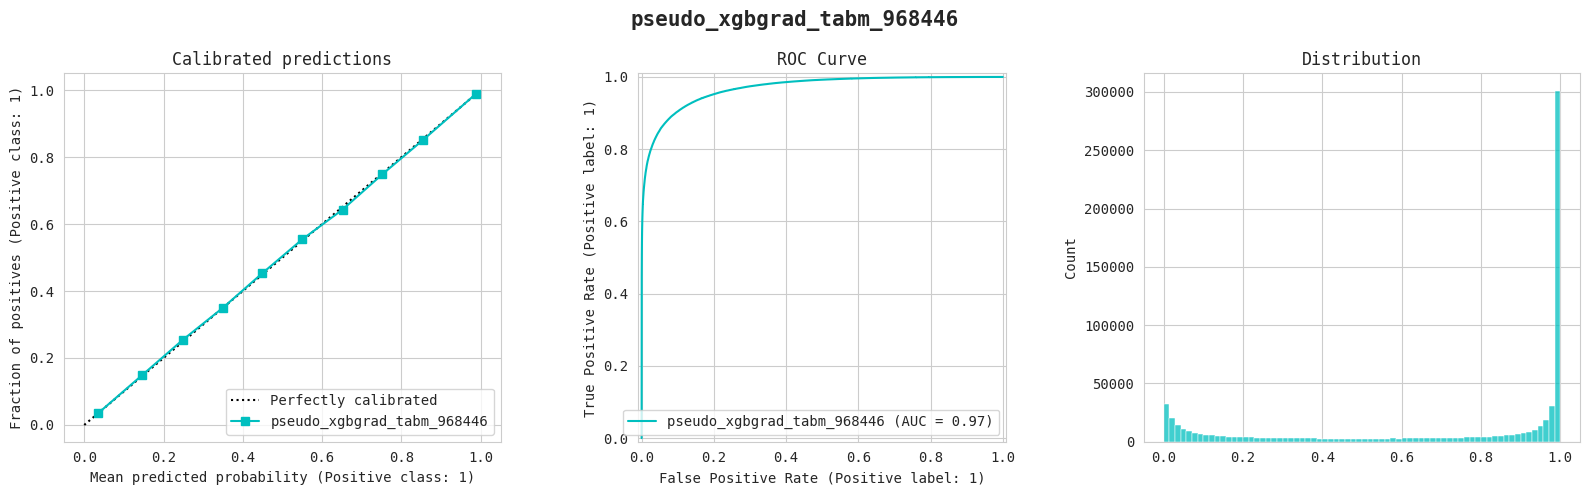

In [31]:
## -- Plot predictions errors --
name = f"pseudo_xgb{XGB_TYPE}_{m1_name}_" + str(oof_score).split('.')[1]
 
_, axs = plt.subplots(1, 3, figsize=(16, 5))

CalibrationDisplay.from_predictions(y, oof_preds, n_bins=10, name=name, ax=axs[0])
axs[0].set_title("Calibrated predictions")

RocCurveDisplay.from_predictions(y, oof_preds, name=name, ax=axs[1])
axs[1].set_title("ROC Curve")
# axs[1].grid(False)

sns.histplot(oof_preds, ax=axs[2])
axs[2].set_title("Distribution")

plt.suptitle(name, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

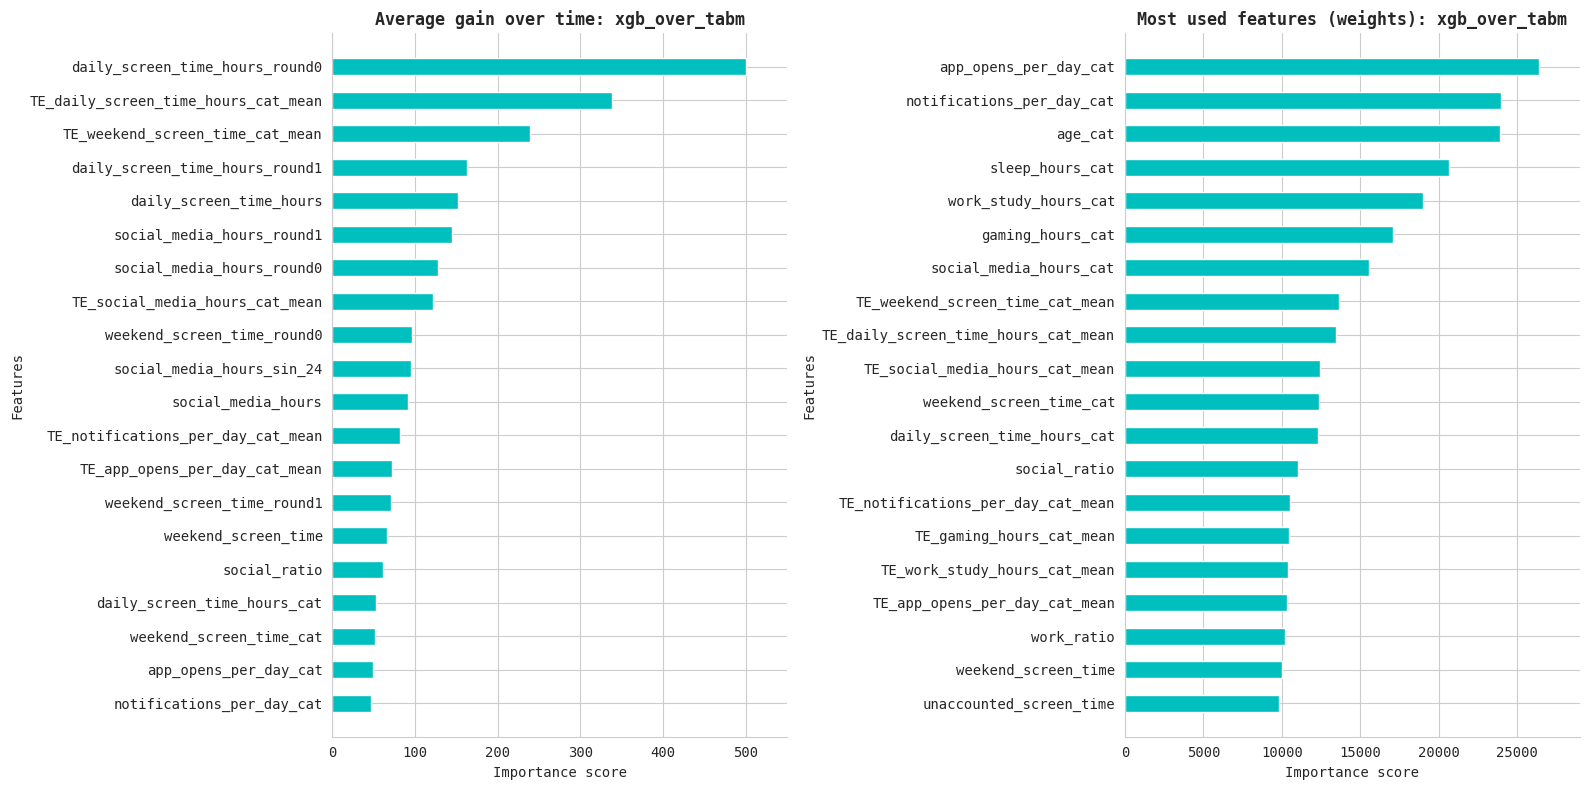

In [32]:
## -- Plot Feature Importances --
MAX = 20

_, axs = plt.subplots(1, 2, figsize=(16, 8))
xgb.plot_importance(
    model_2, ax=axs[0],
    max_num_features=MAX,
    importance_type='gain',
    height=0.5, show_values=False, #grid=False,
)
axs[0].set_title(f"Average gain over time: xgb_over_{m1_name}", fontdict={'weight': 'bold'})

xgb.plot_importance(
    model_2, ax=axs[1],
    max_num_features=MAX,
    importance_type='weight',
    height=0.5, show_values=False, #grid=False,
)
axs[1].set_title(f"Most used features (weights): xgb_over_{m1_name}", fontdict={'weight': 'bold'})

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## SUBMISSION

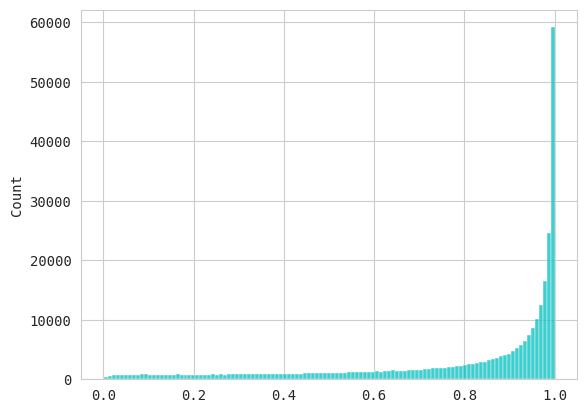

,id,addicted_label
0,691369,0.931176
1,691370,0.311223
2,691371,0.562221
3,691372,0.170041
4,691373,0.944442
...,...,...
296297,987666,0.999660
296298,987667,0.983319
296299,987668,0.962008
296300,987669,0.753000


In [33]:
## -- Save oof/test predictions --

np.save(f"oof_{name}.npy", oof_preds)
np.save(f"test_{name}.npy", test_preds)

## -- Save submission file --
submit[TARGET] = test_preds
submit.to_csv(f"submit_{name}.csv", index=False)

sns.histplot(submit[TARGET].values)
plt.show()

submit

In [34]:
# !rm -r /kaggle/working